# Deliverable 6c — 2.5D U-Net with Stack Size 5

**Single-variable change vs D6**: increase `STACK_SIZE` from 3 to 5.

D6 (stack=3) was the only clean win across D3-D6, gaining +0.030 Tumor Dice over baseline by giving the network adjacent-slice context. The natural follow-up: does **more** context keep helping?

- If **stack=5 wins**: spatial context was undersold in D6 — not just "the right idea" but a knob worth turning further.
- If **stack=5 ties or loses**: 3 slices is enough; more context dilutes the middle-slice signal.

Either result is a clean experimental finding. Loss, optimizer, schedule, split — all identical to D6.

## 1. Imports

In [10]:
import os, json, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import DataLoader

from lits_core import (get_device, load_lits_paths, make_split,
                       LiTS25DDataset, UNet2D, train_model)

device = get_device()
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

Device: mps
PyTorch: 2.11.0


## 2. Configuration

**Only change vs D6: `STACK_SIZE = 5` instead of 3.**

In [11]:
DATA_DIR    = '/Users/aemanadnan/Desktop/DL proj/archive-2'
OUT_DIR     = './out_d6c'
TAG         = 'D6c'

IMG_SIZE    = 128
BATCH_SIZE  = 16
NUM_EPOCHS  = 15
LR          = 1e-4
SEED        = 42

STACK_SIZE  = 5   

os.makedirs(OUT_DIR, exist_ok=True)
print(f'Stack size: {STACK_SIZE}')
print(f'Input shape per sample: (B, {STACK_SIZE}, {IMG_SIZE}, {IMG_SIZE})')

Stack size: 5
Input shape per sample: (B, 5, 128, 128)


## 3. Data Loading & Split (identical to D6)

In [12]:
volume_paths, seg_paths = load_lits_paths(DATA_DIR)
train_v, train_s, val_v, val_s, test_v, test_s = make_split(
    volume_paths, seg_paths, seed=SEED)

Found 51 matched volume-segmentation pairs
Split — Train: 35 | Val: 8 | Test: 8


## 4. Build 2.5D Datasets — `stack_size=5`

In [13]:
print('Building train dataset (stack=5)...')
train_dataset = LiTS25DDataset(train_v, train_s, img_size=IMG_SIZE,
                               stack_size=STACK_SIZE, augment=False)
print()
print('Building val dataset (stack=5)...')
val_dataset = LiTS25DDataset(val_v, val_s, img_size=IMG_SIZE,
                             stack_size=STACK_SIZE, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f'\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Building train dataset (stack=5)...
Dataset: 4614 slices | stack=5 | augment=False (medium) | noise=None@0% (0 slices)

Building val dataset (stack=5)...
Dataset: 1116 slices | stack=5 | augment=False (medium) | noise=None@0% (0 slices)

Train batches: 289 | Val batches: 70


## 5. Sanity Check — Visualize a 5-Slice Stack

CT batch shape: torch.Size([16, 5, 128, 128])  (B, 5, H, W)
Seg batch shape: torch.Size([16, 128, 128])


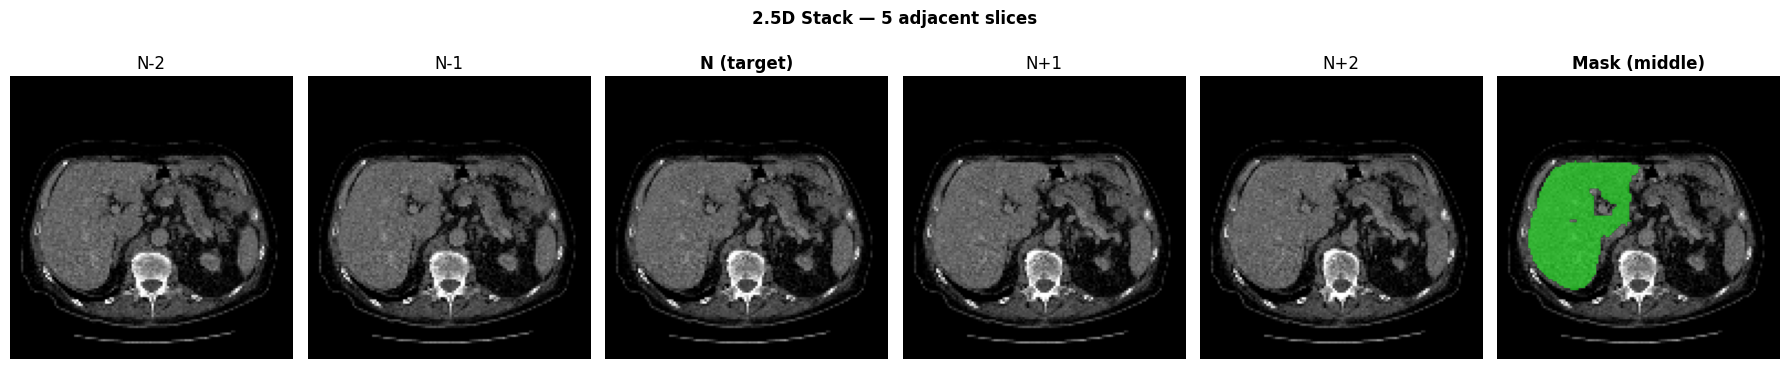

In [14]:
ct_batch, seg_batch = next(iter(train_loader))
print(f'CT batch shape: {ct_batch.shape}  (B, {STACK_SIZE}, H, W)')
print(f'Seg batch shape: {seg_batch.shape}')

fig, axes = plt.subplots(1, STACK_SIZE + 1, figsize=(3 * (STACK_SIZE + 1), 4))
sample_ct  = ct_batch[0].numpy()    # (5, H, W)
sample_seg = seg_batch[0].numpy()   # (H, W)

for i in range(STACK_SIZE):
    axes[i].imshow(sample_ct[i].T, cmap='gray', origin='lower')
    label = ['N-2', 'N-1', 'N (target)', 'N+1', 'N+2'][i]
    axes[i].set_title(label, fontweight='bold' if i == 2 else 'normal')
    axes[i].axis('off')

overlay = np.zeros((*sample_seg.shape, 4))
overlay[sample_seg == 1] = [0, 1, 0, 0.5]
overlay[sample_seg == 2] = [1, 0, 0, 0.7]
axes[-1].imshow(sample_ct[STACK_SIZE // 2].T, cmap='gray', origin='lower')
axes[-1].imshow(overlay.transpose(1, 0, 2), origin='lower')
axes[-1].set_title('Mask (middle)', fontweight='bold')
axes[-1].axis('off')

plt.suptitle(f'2.5D Stack — {STACK_SIZE} adjacent slices', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Build Model — `in_channels = STACK_SIZE`

In [15]:
model = UNet2D(in_channels=STACK_SIZE, num_classes=3, base_features=64,
               use_attention=False).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')
print(f'Input channels: {STACK_SIZE}  (was 3 in D6, +{(STACK_SIZE - 3) * 64 * 9 * 1} extra params in conv1)')

Model parameters: 31,038,915
Input channels: 5  (was 3 in D6, +1152 extra params in conv1)


## 7. Train

Using the shared training loop. Same Adam (lr=1e-4, wd=1e-5), same `ReduceLROnPlateau` scheduler watching Tumor Dice — identical to D6.

In [16]:
history, best_state, best_tumor = train_model(
    model, train_loader, val_loader, device,
    num_epochs=NUM_EPOCHS, lr=LR, tag=TAG,
    save_path=os.path.join(OUT_DIR, 'best_unet_d6c.pth'),
    seed=SEED,
)

TRAINING: D6c
  Epochs=15 | LR=0.0001 | Device=mps | Params=31,038,915
  Train batches: 289 | Val batches: 70
  [D6c] Ep 01 batch 100/289 loss=0.9472
  [D6c] Ep 01 batch 200/289 loss=0.7858
[D6c] Ep 01/15 |  6.9min | Train: 0.9174 | Val: 0.6998 | Liver: 0.8706 | Tumor: 0.5165 *** BEST
  [D6c] Ep 02 batch 100/289 loss=0.5854
  [D6c] Ep 02 batch 200/289 loss=0.4774
[D6c] Ep 02/15 |  6.2min | Train: 0.5539 | Val: 0.5528 | Liver: 0.8752 | Tumor: 0.3104
  [D6c] Ep 03 batch 100/289 loss=0.4010
  [D6c] Ep 03 batch 200/289 loss=0.3743
[D6c] Ep 03/15 |  6.1min | Train: 0.4118 | Val: 0.4639 | Liver: 0.8874 | Tumor: 0.4196
  [D6c] Ep 04 batch 100/289 loss=0.2281
  [D6c] Ep 04 batch 200/289 loss=0.3223
[D6c] Ep 04/15 |  5.8min | Train: 0.3104 | Val: 0.4337 | Liver: 0.8846 | Tumor: 0.4905
  [D6c] Ep 05 batch 100/289 loss=0.2536
  [D6c] Ep 05 batch 200/289 loss=0.1368
[D6c] Ep 05/15 |  3.4min | Train: 0.2193 | Val: 0.4110 | Liver: 0.8855 | Tumor: 0.4198
  [D6c] Ep 06 batch 100/289 loss=0.1136
  [D6c

## 8. Results Summary

In [17]:
best_liver = float(np.max(history['val_liver_dice']))
best_ep    = int(np.argmax(history['val_tumor_dice']) + 1)

D3_LIVER, D3_TUMOR = 0.8885, 0.5011
D4_LIVER, D4_TUMOR = 0.8901, 0.4961
D5_LIVER, D5_TUMOR = 0.8886, 0.4774
D6_LIVER, D6_TUMOR = 0.8917, 0.5314

result = {
    'tag': TAG,
    'stack_size': STACK_SIZE,
    'best_tumor_dice': best_tumor,
    'best_liver_dice': best_liver,
    'best_epoch': best_ep,
    'history': history,
}
with open(os.path.join(OUT_DIR, 'results.json'), 'w') as f:
    json.dump(result, f, indent=2)

print('=' * 90)
print(f'D6c RESULTS — 2.5D U-Net with Stack Size {STACK_SIZE}')
print('=' * 90)
print(f'{"":18}{"D3":>10}{"D4":>10}{"D5":>10}{"D6":>10}{"D6c":>10}{"vs D6":>10}{"vs D3":>10}')
print(f'{"Liver Dice":18}{D3_LIVER:>10.4f}{D4_LIVER:>10.4f}{D5_LIVER:>10.4f}{D6_LIVER:>10.4f}'
      f'{best_liver:>10.4f}{best_liver - D6_LIVER:>+10.4f}{best_liver - D3_LIVER:>+10.4f}')
print(f'{"Tumor Dice":18}{D3_TUMOR:>10.4f}{D4_TUMOR:>10.4f}{D5_TUMOR:>10.4f}{D6_TUMOR:>10.4f}'
      f'{best_tumor:>10.4f}{best_tumor - D6_TUMOR:>+10.4f}{best_tumor - D3_TUMOR:>+10.4f}')
print(f'{"Best epoch":18}{8:>10d}{7:>10d}{13:>10d}{8:>10d}{best_ep:>10d}')
print('=' * 90)

delta_d6 = best_tumor - D6_TUMOR
print()
if delta_d6 > 0.01:
    print(f'> Stack=5 IMPROVED Tumor Dice by {delta_d6:+.4f} over D6.')
    print('  Spatial context was undersold in D6 — more slices helped.')
elif delta_d6 > -0.01:
    print(f'> Stack=5 essentially TIED D6 ({delta_d6:+.4f}).')
    print('  3 slices is enough — additional context did not change the result.')
else:
    print(f'> Stack=5 HURT performance ({delta_d6:+.4f} vs D6).')
    print('  Extra context may dilute the middle-slice signal at this resolution.')

D6c RESULTS — 2.5D U-Net with Stack Size 5
                          D3        D4        D5        D6       D6c     vs D6     vs D3
Liver Dice            0.8885    0.8901    0.8886    0.8917    0.8941   +0.0024   +0.0056
Tumor Dice            0.5011    0.4961    0.4774    0.5314    0.5749   +0.0435   +0.0738
Best epoch                 8         7        13         8         7

> Stack=5 IMPROVED Tumor Dice by +0.0435 over D6.
  Spatial context was undersold in D6 — more slices helped.


## 9. Training Curves

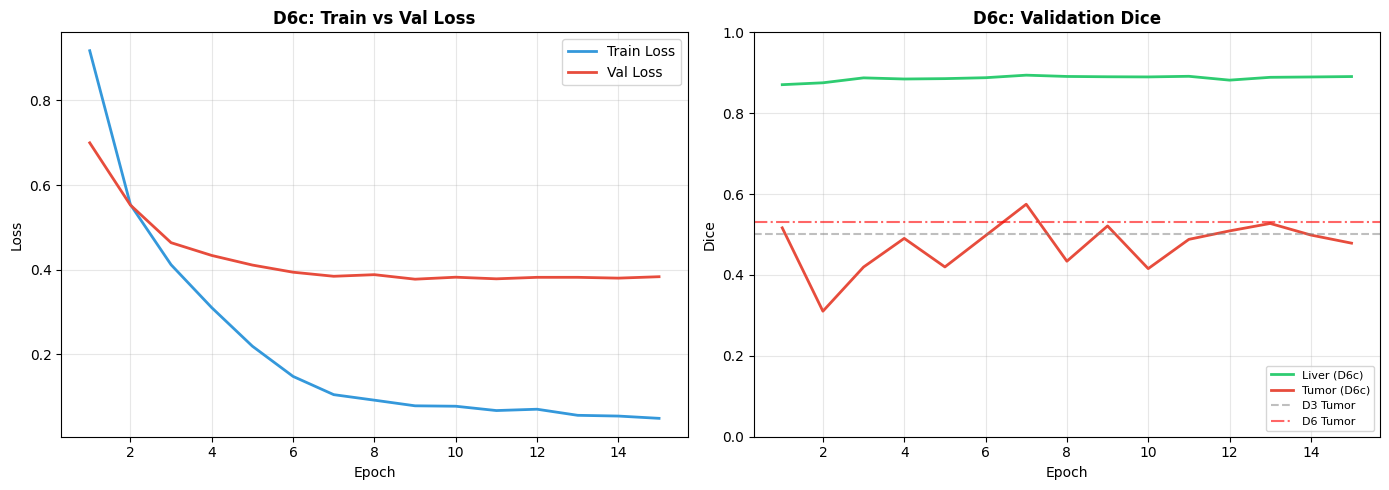

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, NUM_EPOCHS + 1)

axes[0].plot(ep, history['train_loss'], label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(ep, history['val_loss'],   label='Val Loss',   color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('D6c: Train vs Val Loss', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['val_liver_dice'], label='Liver (D6c)', color='#2ecc71', linewidth=2)
axes[1].plot(ep, history['val_tumor_dice'], label='Tumor (D6c)', color='#e74c3c', linewidth=2)
axes[1].axhline(D3_TUMOR, ls='--',  color='gray',   alpha=0.5, label='D3 Tumor')
axes[1].axhline(D6_TUMOR, ls='-.',  color='red',    alpha=0.6, label='D6 Tumor')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Dice')
axes[1].set_ylim(0, 1)
axes[1].set_title('D6c: Validation Dice', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'training_curves_d6c.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Qualitative Predictions

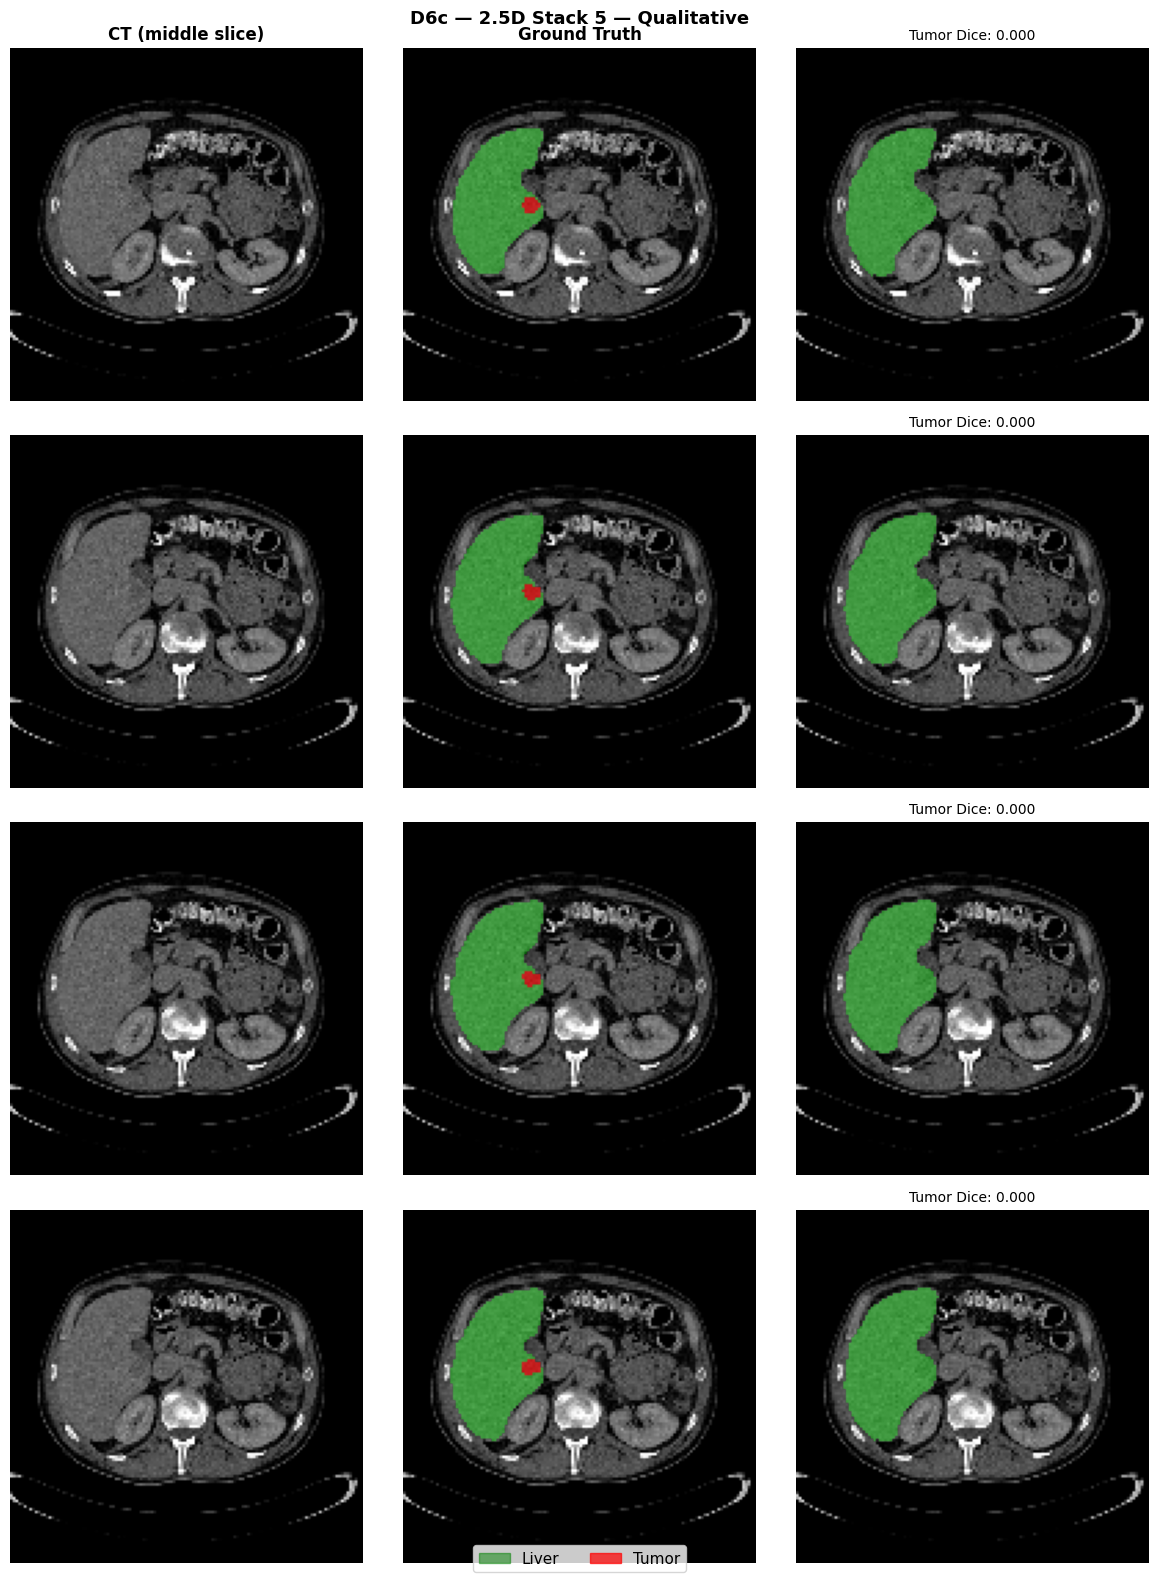

In [19]:
model.load_state_dict(best_state)
model.eval()

samples = []
with torch.no_grad():
    for ct_batch, seg_batch in val_loader:
        ct_batch = ct_batch.to(device); seg_batch = seg_batch.to(device)
        preds    = model(ct_batch)
        pred_cls = preds.argmax(dim=1)
        for i in range(ct_batch.shape[0]):
            gt = seg_batch[i].cpu().numpy()
            if (gt == 2).sum() > 30:
                mid = STACK_SIZE // 2
                samples.append({
                    'ct':   ct_batch[i, mid].cpu().numpy(),
                    'gt':   gt,
                    'pred': pred_cls[i].cpu().numpy(),
                })
        if len(samples) >= 4: break

def overlay(seg, ct):
    o = np.zeros((*ct.shape, 4))
    o[seg == 1] = [0, 1, 0, 0.35]
    o[seg == 2] = [1, 0, 0, 0.65]
    return o

n = min(4, len(samples))
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
if n == 1: axes = [axes]
for col, t in enumerate(['CT (middle slice)', 'Ground Truth', 'Prediction']):
    axes[0][col].set_title(t, fontsize=12, fontweight='bold')
for row, s in enumerate(samples[:n]):
    ct, gt, pr = s['ct'], s['gt'], s['pred']
    axes[row][0].imshow(ct.T, cmap='gray', origin='lower'); axes[row][0].axis('off')
    axes[row][1].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][1].imshow(overlay(gt, ct).transpose(1,0,2), origin='lower'); axes[row][1].axis('off')
    axes[row][2].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][2].imshow(overlay(pr, ct).transpose(1,0,2), origin='lower')
    pt, gt_t = (pr == 2).astype(float), (gt == 2).astype(float)
    inter, denom = (pt * gt_t).sum(), pt.sum() + gt_t.sum()
    sd = (2 * inter / denom) if denom > 0 else 1.0
    axes[row][2].set_title(f'Tumor Dice: {sd:.3f}', fontsize=10); axes[row][2].axis('off')

g = mpatches.Patch(color='green', alpha=0.5, label='Liver')
r = mpatches.Patch(color='red',   alpha=0.7, label='Tumor')
fig.legend(handles=[g, r], loc='lower center', ncol=2, fontsize=11)
plt.suptitle(f'D6c — 2.5D Stack {STACK_SIZE} — Qualitative', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'qualitative_d6c.png'), dpi=150, bbox_inches='tight')
plt.show()

Total val slices with tumor (>30px): 184
  Mean per-slice tumor Dice : 0.1750
  Median per-slice tumor Dice: 0.0000
  % of slices with Dice > 0.3: 20.1%


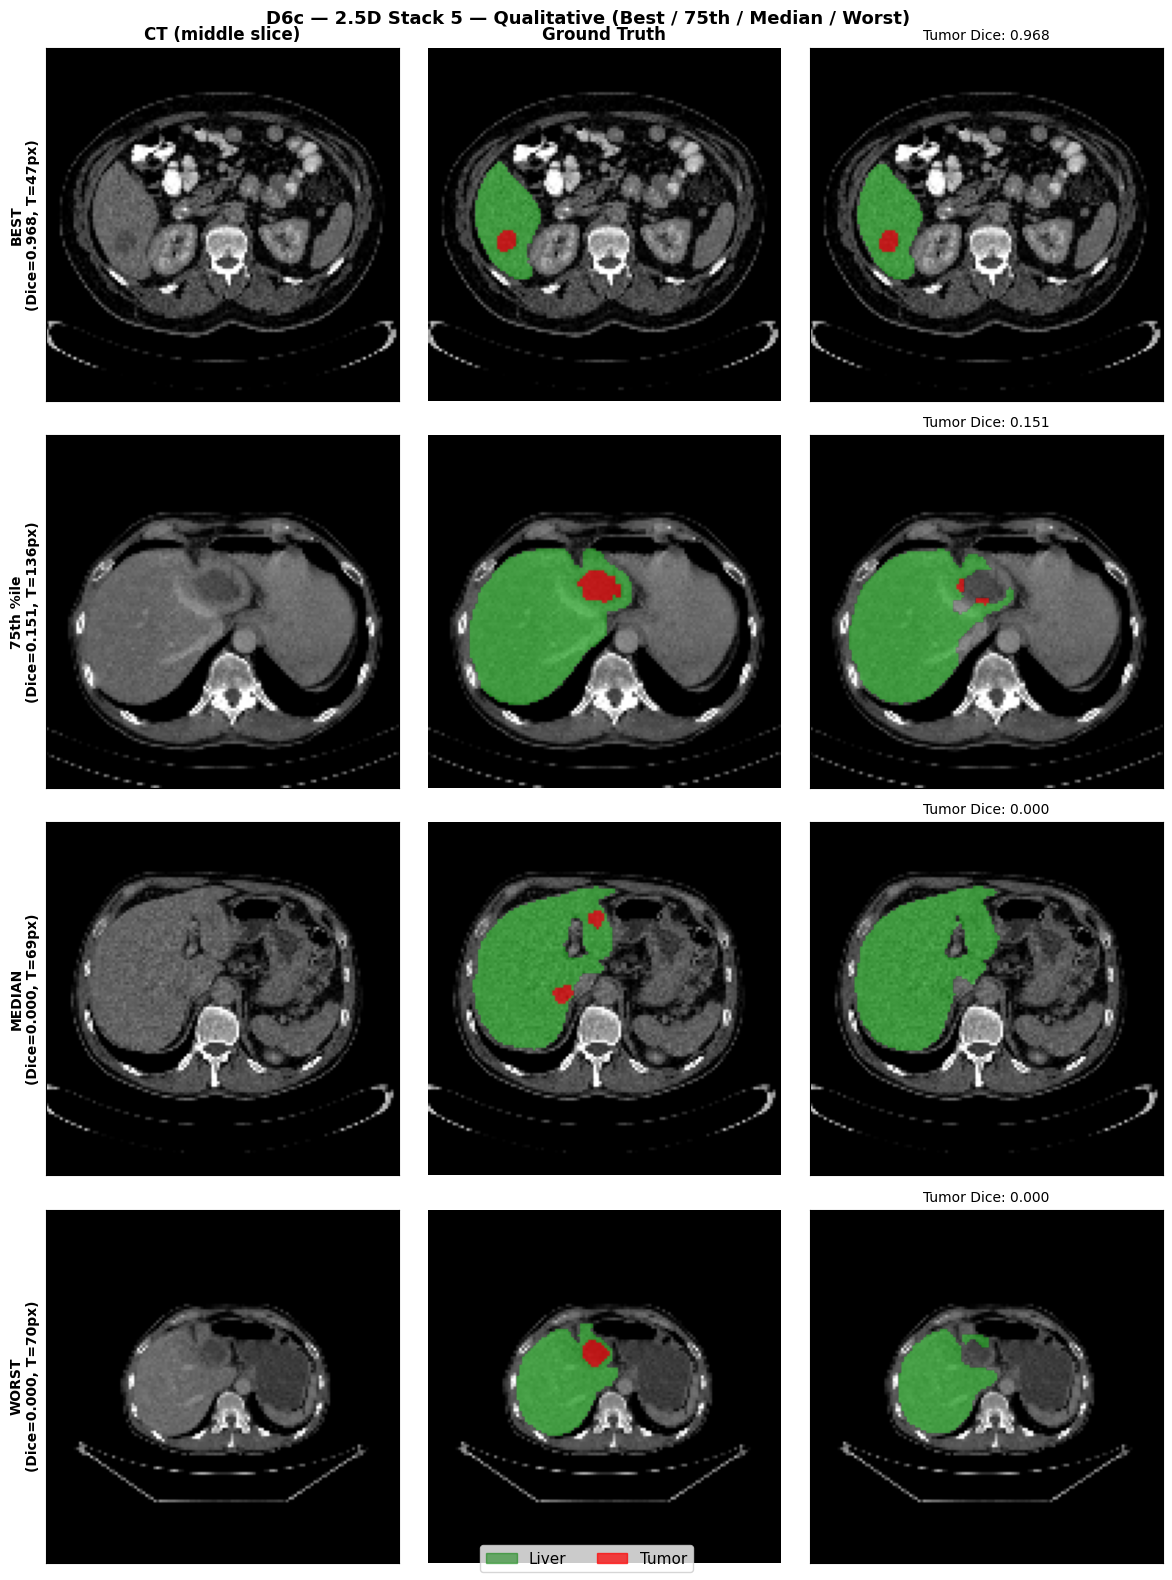

: 

In [ ]:
model.load_state_dict(best_state)
model.eval()

samples_all = []
with torch.no_grad():
    for ct_batch, seg_batch in val_loader:
        ct_batch = ct_batch.to(device); seg_batch = seg_batch.to(device)
        preds    = model(ct_batch)
        pred_cls = preds.argmax(dim=1)
        for i in range(ct_batch.shape[0]):
            gt = seg_batch[i].cpu().numpy()
            if (gt == 2).sum() < 30:
                continue
            pr = pred_cls[i].cpu().numpy()
            pt, gt_t = (pr == 2).astype(float), (gt == 2).astype(float)
            inter, denom = (pt * gt_t).sum(), pt.sum() + gt_t.sum()
            sd = (2 * inter / denom) if denom > 0 else 0.0
            mid = STACK_SIZE // 2
            samples_all.append({
                'ct':   ct_batch[i, mid].cpu().numpy(),
                'gt':   gt,
                'pred': pr,
                'dice': sd,
                'tumor_px': int((gt == 2).sum()),
            })

print(f'Total val slices with tumor (>30px): {len(samples_all)}')
if len(samples_all) > 0:
    dices = [s['dice'] for s in samples_all]
    print(f'  Mean per-slice tumor Dice : {np.mean(dices):.4f}')
    print(f'  Median per-slice tumor Dice: {np.median(dices):.4f}')
    print(f'  % of slices with Dice > 0.3: {np.mean([d > 0.3 for d in dices]) * 100:.1f}%')

samples_all.sort(key=lambda s: s['dice'], reverse=True)
n_total = len(samples_all)
if n_total >= 4:
    picks = [(0, 'BEST'),
             (n_total // 4, '75th %ile'),
             (n_total // 2, 'MEDIAN'),
             (n_total - 1, 'WORST')]
else:
    picks = [(i, f'#{i+1}') for i in range(n_total)]

samples = [samples_all[i] for i, _ in picks]
labels  = [lbl for _, lbl in picks]

def overlay(seg, ct):
    o = np.zeros((*ct.shape, 4))
    o[seg == 1] = [0, 1, 0, 0.35]
    o[seg == 2] = [1, 0, 0, 0.65]
    return o

n = len(samples)
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
if n == 1: axes = [axes]
for col, t in enumerate(['CT (middle slice)', 'Ground Truth', 'Prediction']):
    axes[0][col].set_title(t, fontsize=12, fontweight='bold')

for row, (s, lbl) in enumerate(zip(samples, labels)):
    ct, gt, pr, sd = s['ct'], s['gt'], s['pred'], s['dice']

    axes[row][0].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][0].set_ylabel(f'{lbl}\n(Dice={sd:.3f}, T={s["tumor_px"]}px)',
                            fontsize=10, fontweight='bold')
    axes[row][0].set_xticks([]); axes[row][0].set_yticks([])

    axes[row][1].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][1].imshow(overlay(gt, ct).transpose(1,0,2), origin='lower')
    axes[row][1].axis('off')

    axes[row][2].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][2].imshow(overlay(pr, ct).transpose(1,0,2), origin='lower')
    axes[row][2].set_title(f'Tumor Dice: {sd:.3f}', fontsize=10)
    axes[row][2].set_xticks([]); axes[row][2].set_yticks([])

g = mpatches.Patch(color='green', alpha=0.5, label='Liver')
r = mpatches.Patch(color='red',   alpha=0.7, label='Tumor')
fig.legend(handles=[g, r], loc='lower center', ncol=2, fontsize=11)
plt.suptitle(f'D6c — 2.5D Stack {STACK_SIZE} — Qualitative (Best / 75th / Median / Worst)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'qualitative_d6c.png'), dpi=150, bbox_inches='tight')
plt.show()